In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np
import math


def get_avg_conf(out, dataset_name):
    outs = []
    for sample in out["samples"][dataset_name]:
        resps = [math.exp(x[0]) for x in sample["filtered_resps"]]
        outs.append(max(resps)/sum(resps))

    return sum(outs)/len(outs)

def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets):


    d_names = {
        "rte":"RTE",
        "arc_challenge":"ARC Challenge",
        "openbookqa":"OpenBookQA",
        "boolq":"BoolQ",
        "arc_easy":"ARC Easy"
    }

    num = 16
        
    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        if tmp_path_unpruned is not None:
            conf = 0
            
            out_file = open(tmp_path_unpruned+model_name+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            conf = get_avg_conf(out, dataset)
            acc = out["results"][dataset]["acc,none"]
            
    
        confs = []
        accs = []

        for i in range(num):
            
            out_file = open(tmp_path+model_name+"_"+str(i)+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            confs.append(get_avg_conf(out, dataset))
            accs.append(out["results"][dataset]["acc,none"])
       

        
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()

        x_values = list(range(1, len(confs) + 1))
        # Plotting the data
        l = len(x_values)
        

        lns5 = ax1.plot(x_values, [conf]*l, label='avg confidence unpruned', color="red", linestyle='--')
        lns6 = ax1.plot(x_values, confs, label='avg confidence', color="red")
        
        lns5 = ax2.plot(x_values, [acc]*l, label='accuracy unpruned', color="black", linestyle='--')
        lns6 = ax2.plot(x_values, accs, label='accuracy', color="black")

        # Adding labels and title
        
        if "stra" in model_name:
            plt.title(d_names[dataset]+", Mistral", fontsize=22)
        else:
            plt.title(d_names[dataset]+", Llama-2", fontsize=22)
        ax1.set_xlabel("# removed attention layers", fontsize=18)
        ax1.set_ylabel("Avg predictions confidence", fontsize=18)
        ax2.set_ylabel("Accuracy", fontsize=18)
        plt.xticks(np.arange(2, 17, 2))
        ax1.tick_params(axis='both', which='major', labelsize=14)
        ax2.tick_params(axis='y', which='major', labelsize=14)
        plt.xlim(1,16)
    
        fig.tight_layout()
        plt.savefig("results/plots/confidence/confidence_"+dataset+"_"+model_name+".pdf", dpi=600)
        plt.show()

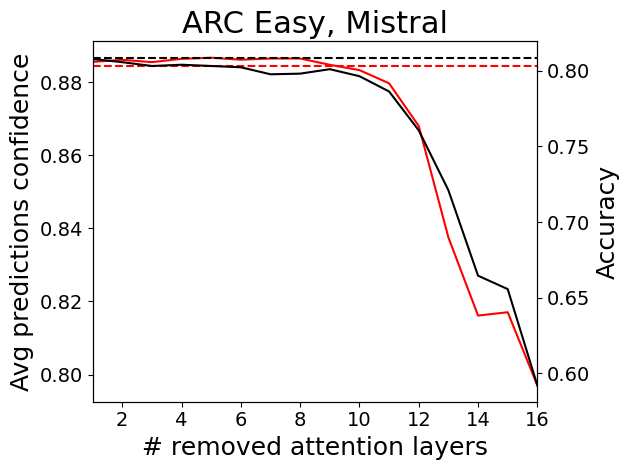

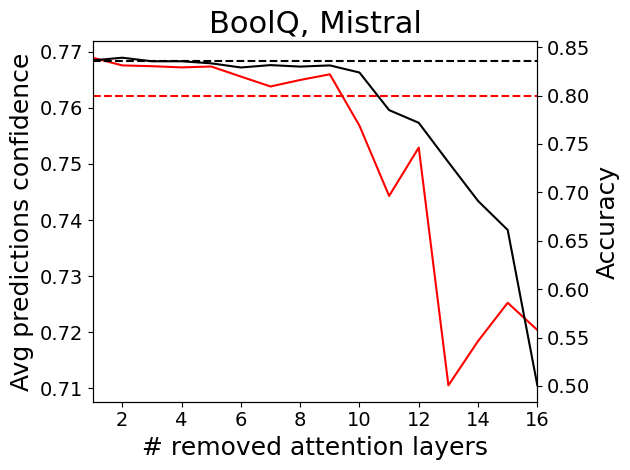

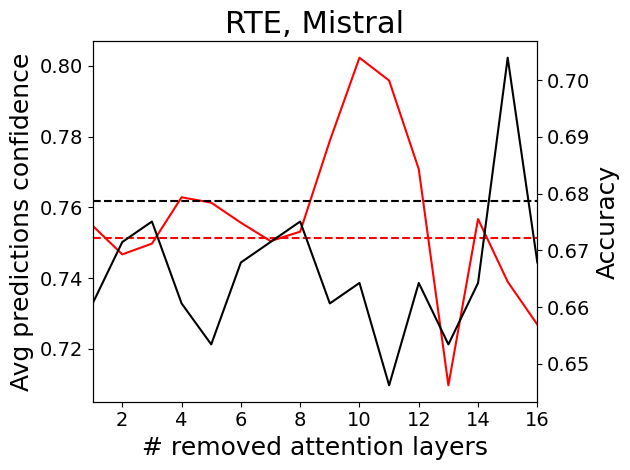

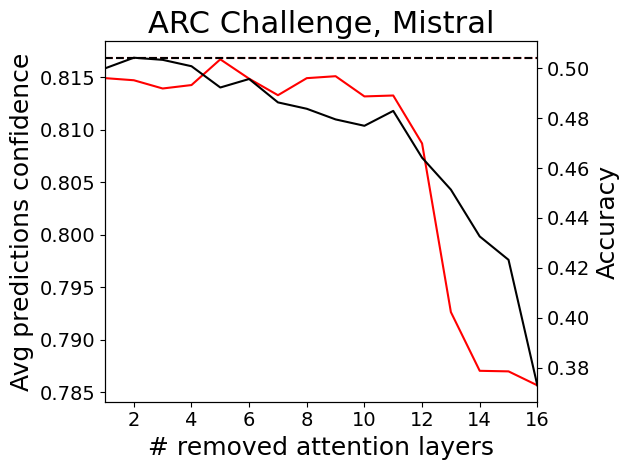

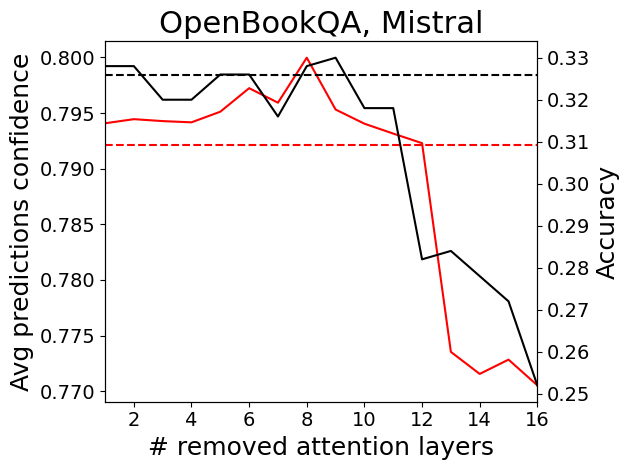

In [3]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/mistralai/"

plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/meta-llama/"
tmp_path_unpruned = "./results/unpruned/meta-llama/"

plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets)

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np
import math

def get_conf_acc(out, dataset_name):
    outs = []
    accs = []
    for sample in out["samples"][dataset_name]:
        resps = [math.exp(x[0]) for x in sample["filtered_resps"]]
        conf = max(resps)/sum(resps)
        outs.append(conf)
        accs.append(sample["acc"])
    return outs, accs

def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets):
    
    
    d_names = {
        "rte":"RTE",
        "arc_challenge":"ARC Challenge",
        "openbookqa":"OpenBookQA",
        "boolq":"BoolQ",
        "arc_easy":"ARC Easy"
    }


    conf = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

    num = 16
    if "gemma" in model_name:
        num = 9
        
    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        if tmp_path_unpruned is not None:
            conf_unp = 0
            
            out_file = open(tmp_path_unpruned+model_name+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            conf_unp, acc = get_conf_acc(out, dataset)
            
            
        # Compute initial ECE for unpruned model
        ECE_unpruned = 0
        
        
        counter = [[],[],[],[],[],[],[],[],[],[]]
        conf_counter = [[],[],[],[],[],[],[],[],[],[]]
        
        for j in range(len(conf_unp)):
            for k in range(1,len(conf)):
                if conf_unp[j] < conf[0]:
                    counter[0].append(acc[j])
                    conf_counter[0].append(conf_unp[j])
                    break
                elif conf[k-1] <= conf_unp[j] < conf[k]:
                    counter[k].append(acc[j])
                    conf_counter[k].append(conf_unp[j])
                    break
        
        result = [sum(x)/len(x) if len(x) > 0 else 0 for x in counter]
        confid = [sum(x)/len(x) if len(x) > 0 else 0 for x in conf_counter]
        
        ece = sum([(len(counter[s])*abs(res - confid[s]))/len(conf_unp) for s, res in enumerate(result)])
        
        ECE_unpruned = ece
        
        acc = np.array(out["results"][dataset]["acc,none"])
            
        
    
        confs = []
        accs = []
        accs2 = []

        for i in range(num):
            
            out_file = open(tmp_path+model_name+"_"+str(i)+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            tmp1, tmp2 = get_conf_acc(out, dataset)
            confs.append(tmp1)
            accs.append(tmp2)
            accs2.append(np.array(out["results"][dataset]["acc,none"]))
       
        ECE = []
        for i in range(num):

            
            
            counter = [[],[],[],[],[],[],[],[],[],[]]
            conf_counter = [[],[],[],[],[],[],[],[],[],[]]
            
            for j in range(len(confs[i])):
                for k in range(1,len(conf)):
                    if confs[i][j] < conf[0]:
                        counter[0].append(accs[i][j])
                        conf_counter[0].append(confs[i][j])
                        break
                    elif conf[k-1] <= confs[i][j] < conf[k]:
                        counter[k].append(accs[i][j])
                        conf_counter[k].append(confs[i][j])
                        break
            
            result = [sum(x)/len(x) if len(x) > 0 else 0 for x in counter]
            confid = [sum(x)/len(x) if len(x) > 0 else 0 for x in conf_counter]
            
            ece = sum([(len(counter[s])*abs(res - confid[s]))/len(confs[i]) for s, res in enumerate(result)])
            
            ECE.append(ece)
           
        
        fig, ax1 = plt.subplots()
        x_axis = range(1,len(ECE)+1)
         
        ax1.plot(x_axis, ECE, label='ECE', color="green")
        ax1.plot(x_axis, [ECE_unpruned]*len(x_axis), label='ECE unpruned', color="green", linestyle='--')
                
        ax1.set_xlabel("# removed attention layers", fontsize=18)
        ax1.set_ylabel('ECE', fontsize=18)
        plt.xticks(np.arange(2, 17, 2))
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.xlim(1,16)
        
        if "stra" in model_name:
            plt.title(d_names[dataset]+", Mistral", fontsize=22)
        else:
            plt.title(d_names[dataset]+", Llama-2", fontsize=22)
        
        fig.tight_layout()
        plt.savefig("results/plots/confidence/ECE_"+dataset+"_"+model_name+".pdf", dpi=600)
        plt.show()

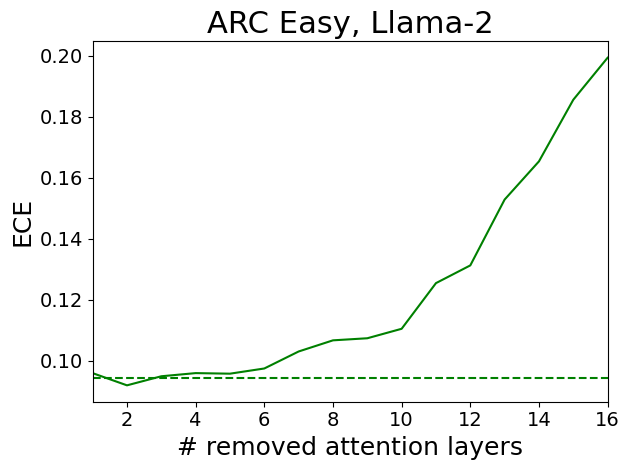

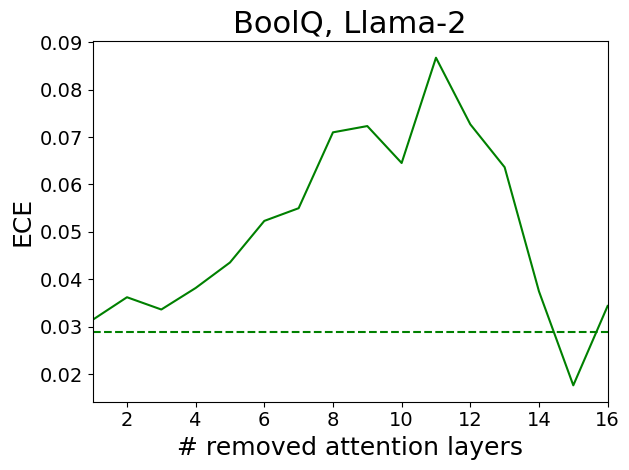

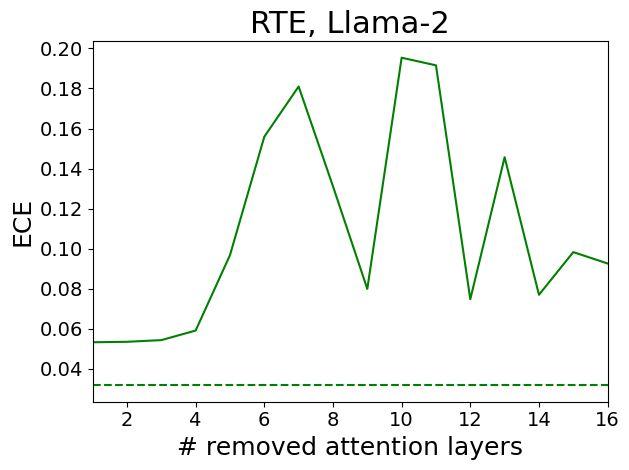

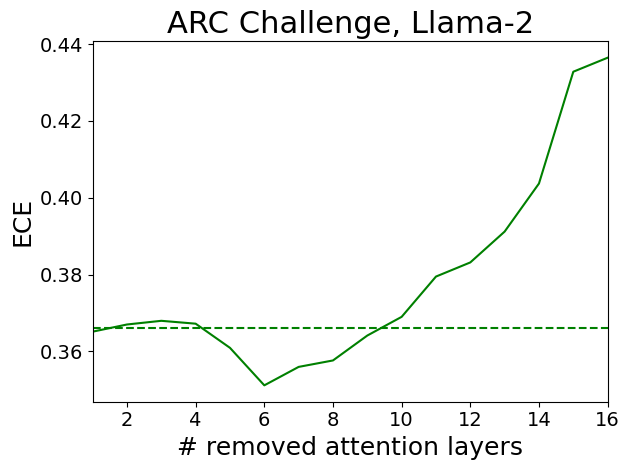

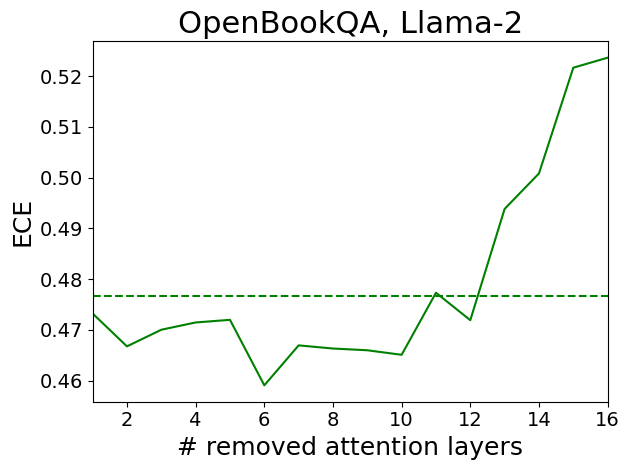

In [6]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/meta-llama/"
tmp_path_unpruned = "./results/unpruned/meta-llama/"

plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/mistralai/"

plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets)

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np
import math



def get_conf_acc(out, dataset_name):
    outs = []
    accs = []
    for sample in out["samples"][dataset_name]:
        resps = [math.exp(x[0]) for x in sample["filtered_resps"]]
        conf = max(resps)/sum(resps)
        outs.append(conf)
        accs.append(sample["acc"])
    return outs, accs

def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets):
    
    
    d_names = {
        "rte":"RTE",
        "arc_challenge":"ARC Challenge",
        "openbookqa":"OpenBookQA",
        "boolq":"BoolQ",
        "arc_easy":"ARC Easy"
    }


    conf = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

    num = 16

        
    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        if tmp_path_unpruned is not None:
            conf_unp = 0
            
            out_file = open(tmp_path_unpruned+model_name+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            conf_unp, acc = get_conf_acc(out, dataset)

            
        # Compute initial ECE for unpruned model
        ECE_unpruned = 0
        
        
        counter = [[],[],[],[],[],[],[],[],[],[]]
        conf_counter = [[],[],[],[],[],[],[],[],[],[]]
        
        for j in range(len(conf_unp)):
            for k in range(1,len(conf)):
                if conf_unp[j] < conf[0]:
                    counter[0].append(acc[j])
                    conf_counter[0].append(conf_unp[j])
                    break
                elif conf[k-1] <= conf_unp[j] < conf[k]:
                    counter[k].append(acc[j])
                    conf_counter[k].append(conf_unp[j])
                    break
        
        result = [sum(x)/len(x) if len(x) > 0 else 0 for x in counter]
        confid = [sum(x)/len(x) if len(x) > 0 else 0 for x in conf_counter]
        
        ece = sum([(len(counter[s])*abs(res - confid[s]))/len(conf_unp) for s, res in enumerate(result)])
        
        ECE_unpruned = ece
        
        acc = np.array(out["results"][dataset]["acc,none"])
            
        
    
        confs = []
        accs = []
        accs2 = []

        for i in range(num):
            
            out_file = open(tmp_path+model_name+"_"+str(i)+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            tmp1, tmp2 = get_conf_acc(out, dataset)
            confs.append(tmp1)
            accs.append(tmp2)
            accs2.append(np.array(out["results"][dataset]["acc,none"]))
       
        ECE = []
        for i in range(num):

            
            
            counter = [[],[],[],[],[],[],[],[],[],[]]
            conf_counter = [[],[],[],[],[],[],[],[],[],[]]
            
            for j in range(len(confs[i])):
                for k in range(1,len(conf)):
                    if confs[i][j] < conf[0]:
                        counter[0].append(accs[i][j])
                        conf_counter[0].append(confs[i][j])
                        break
                    elif conf[k-1] <= confs[i][j] < conf[k]:
                        counter[k].append(accs[i][j])
                        conf_counter[k].append(confs[i][j])
                        break
            
            result = [sum(x)/len(x) if len(x) > 0 else 0 for x in counter]
            confid = [sum(x)/len(x) if len(x) > 0 else 0 for x in conf_counter]
            
            ece = sum([(len(counter[s])*abs(res - confid[s]))/len(confs[i]) for s, res in enumerate(result)])
            
            ECE.append(ece)
           
        
        fig, ax1 = plt.subplots()
        x_axis = range(1,len(ECE)+1)
        
        ECE_delta = (np.array(ECE_unpruned)-np.array(ECE))/np.array(ECE_unpruned)
        acc_delta = -(np.array(acc)-np.array(accs2))/np.array(acc)
         
        ax1.plot(x_axis, ECE_delta, color="darkgreen")
        ax1.plot(x_axis, acc_delta, color="black")
        ax1.plot(x_axis, [0]*len(x_axis), label='', color="black", linestyle='--')
        
      
                
        ax1.set_xlabel("# removed attention layers", fontsize=18)
        ax1.set_ylabel('Delta\nunpruned is better | pruned is better   ', fontsize=16)
        plt.xticks(np.arange(2, 17, 2))
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.xlim(1,16)
        
        
        ma = max(max(abs(ECE_delta)),max(abs(acc_delta)))   
        mi = - ma
        ax1.set_ylim([mi, ma])
        

        if "stra" in model_name:
            plt.title(d_names[dataset]+", Mistral", fontsize=22)
        else:
            plt.title(d_names[dataset]+", Llama-2", fontsize=22)
        
        fig.tight_layout()
        plt.savefig("results/plots/confidence/delta_ECE_"+dataset+"_"+model_name+".pdf", dpi=600)
        plt.show()

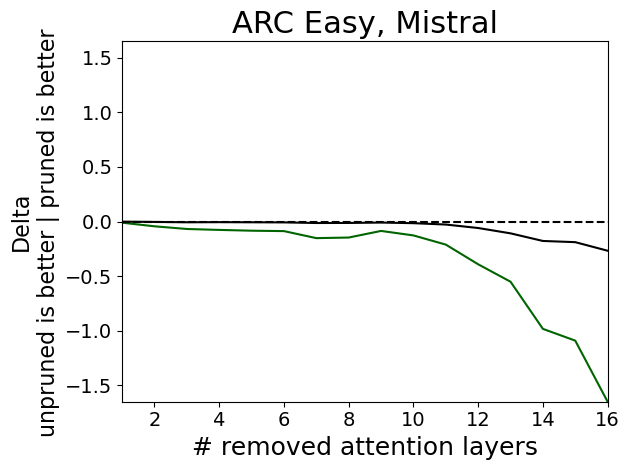

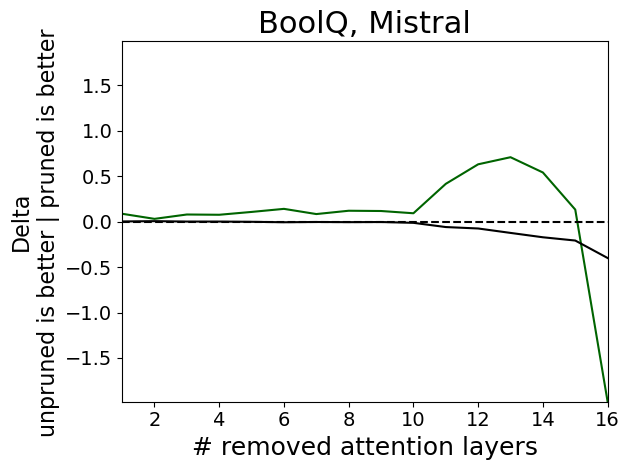

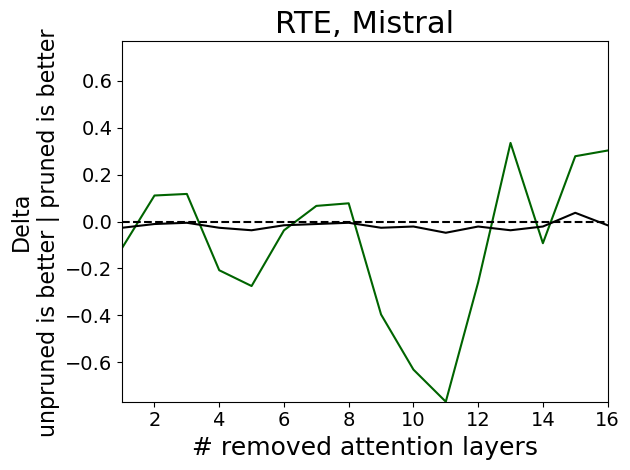

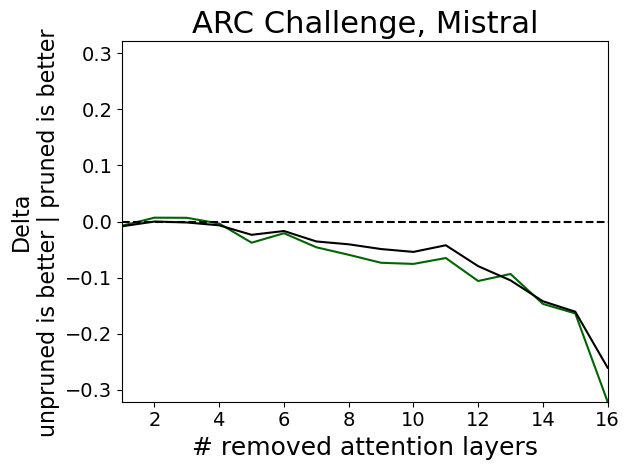

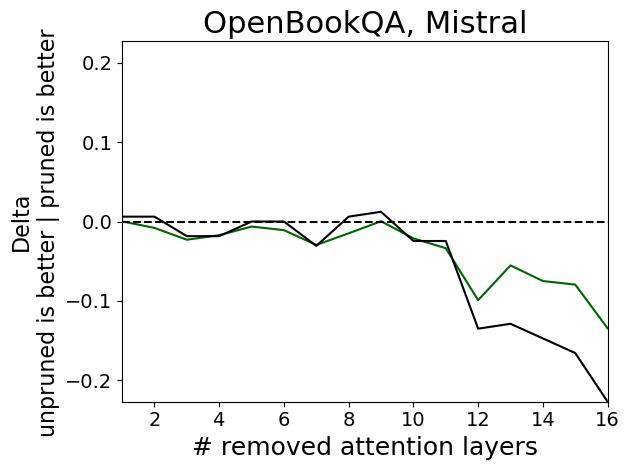

In [9]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/mistralai/"
tmp_path_unpruned = "./results/unpruned/mistralai/"

plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/meta-llama/"
tmp_path_unpruned = "./results/unpruned/meta-llama/"

plot_avg_conf(tmp_path, tmp_path_unpruned, model_name, datasets)